# Mini-projet n°1 – Chats ou Chiens ?

In [1]:
#Utils
import os
import shutil
import time

# Maths - Stats
from sklearn.utils import shuffle
import numpy as np
import pandas as pd
import random as rd

# Data visualization
from matplotlib import pyplot as plt
import seaborn as sns
from PIL import Image

# Deep Learning Librairies
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout,  GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, clone_model, Model,load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16 


2026-01-19 10:21:24.011069: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-19 10:21:30.169502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768814492.219292    5670 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768814492.752266    5670 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768814497.343517    5670 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
[k.device_type for k in tf.config.list_physical_devices()]

['CPU', 'GPU']

In [3]:
df = pd.read_csv(
    "./oxford-iiit-pet/annotations/list.txt",
    sep=r"\s+",                                         
    comment="#",                                        
    header=None,                                        
    names=["Image", "CLASS_ID", "SPECIES", "BREED_ID"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7349 entries, 0 to 7348
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Image     7349 non-null   object
 1   CLASS_ID  7349 non-null   int64 
 2   SPECIES   7349 non-null   int64 
 3   BREED_ID  7349 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 229.8+ KB


Le jeu de données est composé de 7349 individus.
Les variables sont les suivantes :
- Image : au format .jpg ;
- CLASS\_ID (race) : 37 races différentes ;
- SPECIES : chat ou chien (1 ou 2 selon l'espèce) ;
- BREED\_ID : identifiant de la race parmi l'espèce concernée.

Afin de rendre les données plus lisibles, nous rajoutons deux variables non numériques précisant les noms de l'espèce (SPECIES\_NAME) et de la race (BREED\_NAME) de chaque individu.

In [4]:
df["BREED_NAME"] = df["Image"].str.rsplit("_", n=1).str[0]           # Nom de la race
df["SPECIES_NAME"] = df["SPECIES"].map({1: "Cat", 2: "Dog"})         # Chat ou chien
df["Image"] = df["Image"].apply(lambda x: f"{x}.jpg")

print(df.sample(n=3, random_state=42))

                      Image  CLASS_ID  SPECIES  BREED_ID      BREED_NAME  \
2755       keeshond_164.jpg        19        2        13        keeshond   
2966   newfoundland_178.jpg        23        2        16    newfoundland   
5186  great_pyrenees_31.jpg        16        2        10  great_pyrenees   

     SPECIES_NAME  
2755          Dog  
2966          Dog  
5186          Dog  


### Étude de la répartition par race et par type


SPECIES_NAME
Dog    4978
Cat    2371
Name: count, dtype: int64

Pourcentages:
SPECIES_NAME
Dog    67.737107
Cat    32.262893
Name: count, dtype: float64


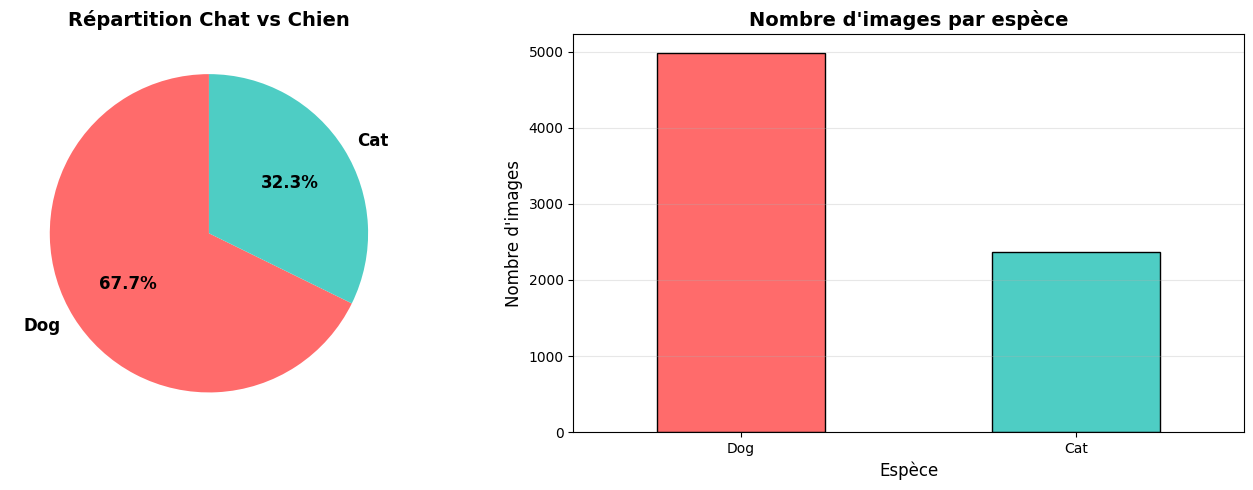

In [5]:
species_counts = df["SPECIES_NAME"].value_counts()
print(f"\n{species_counts}")
print(f"\nPourcentages:")
print(species_counts / len(df) * 100)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#FF6B6B', '#4ECDC4']
axes[0].pie(species_counts, labels=species_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Répartition Chat vs Chien', fontsize=14, weight='bold')

# Bar chart
species_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Nombre d\'images par espèce', fontsize=14, weight='bold')
axes[1].set_xlabel('Espèce', fontsize=12)
axes[1].set_ylabel('Nombre d\'images', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Nombre total de races: 37

Top 10 races les plus représentées:
BREED_NAME
american_bulldog             200
basset_hound                 200
american_pit_bull_terrier    200
beagle                       200
Bengal                       200
yorkshire_terrier            200
Birman                       200
chihuahua                    200
British_Shorthair            200
havanese                     200
Name: count, dtype: int64

Top 10 races les moins représentées:
BREED_NAME
Siamese                       199
boxer                         199
keeshond                      199
scottish_terrier              199
Abyssinian                    198
english_cocker_spaniel        196
newfoundland                  196
Egyptian_Mau                  190
staffordshire_bull_terrier    189
Bombay                        184
Name: count, dtype: int64

📈 Statistiques:
Moyenne d'images par race: 198.62
Médiane: 200.00
Écart-type: 3.52
Min: 184 | Max: 200


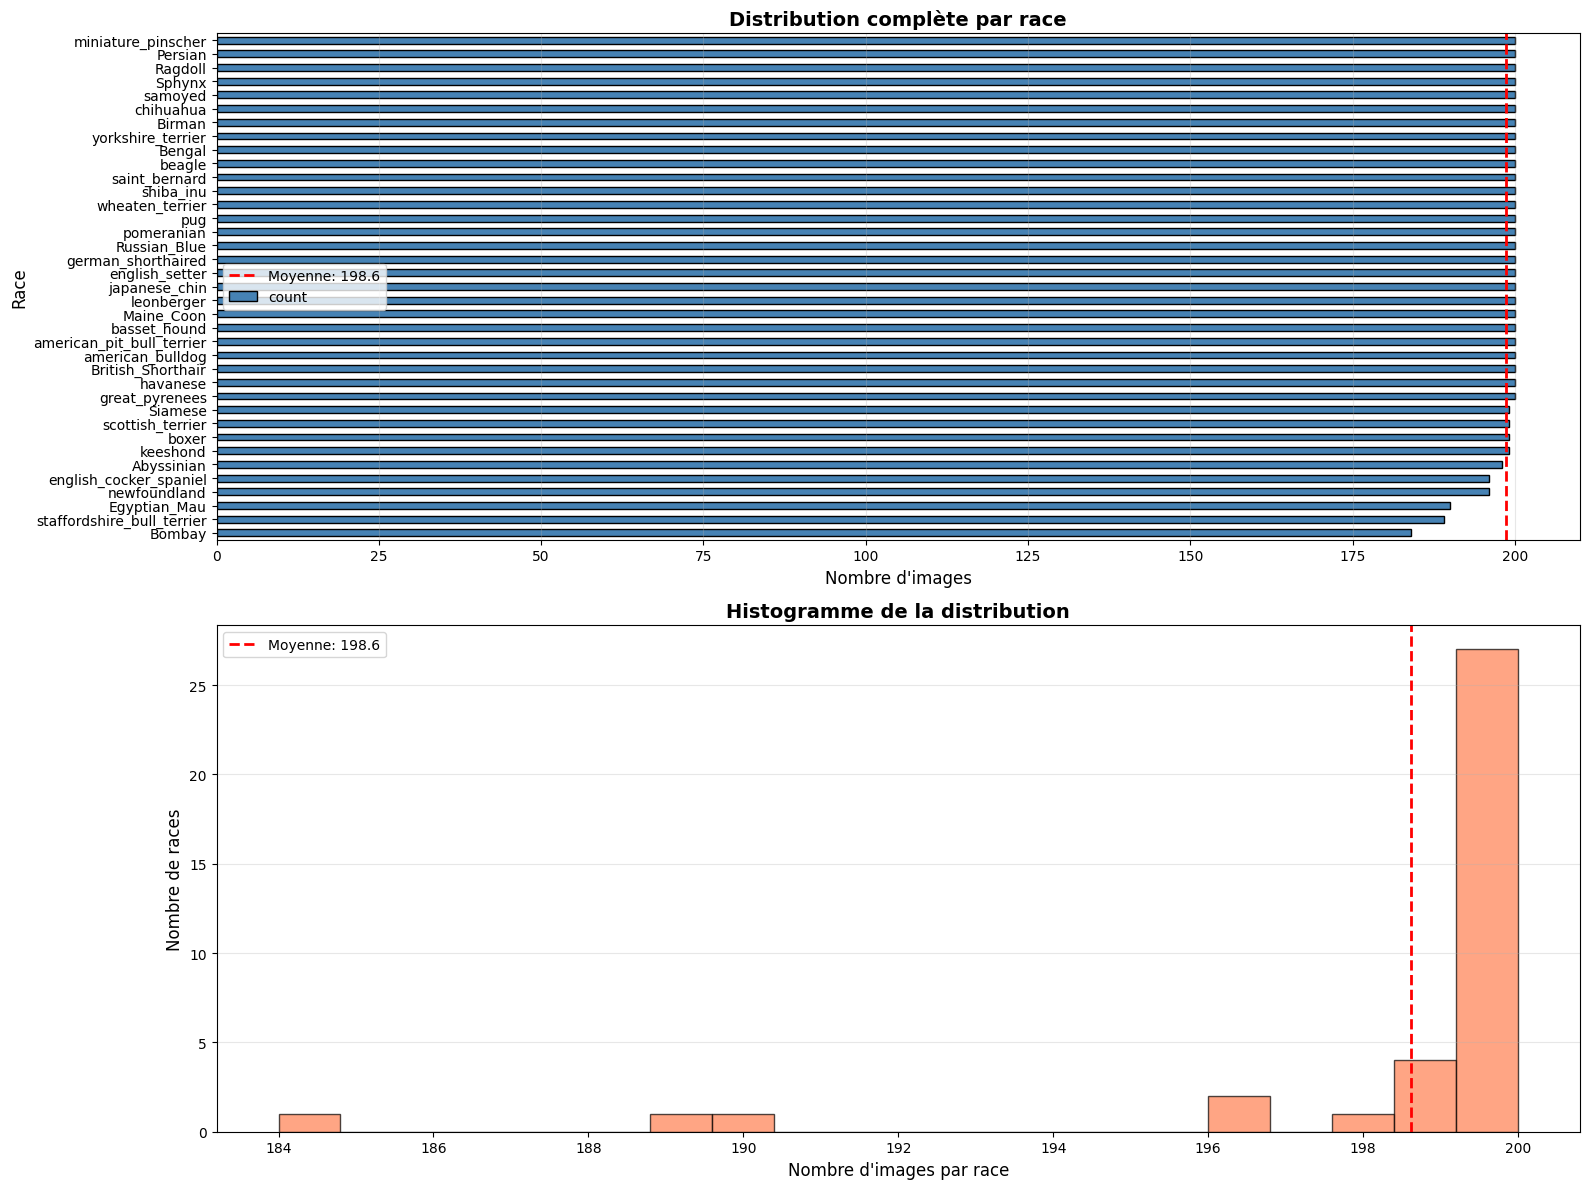

In [6]:
breed_counts = df["BREED_NAME"].value_counts().sort_values(ascending=False)
print(f"\nNombre total de races: {len(breed_counts)}")
print(f"\nTop 10 races les plus représentées:")
print(breed_counts.head(10))
print(f"\nTop 10 races les moins représentées:")
print(breed_counts.tail(10))

# Statistiques
print(f"\n📈 Statistiques:")
print(f"Moyenne d'images par race: {breed_counts.mean():.2f}")
print(f"Médiane: {breed_counts.median():.2f}")
print(f"Écart-type: {breed_counts.std():.2f}")
print(f"Min: {breed_counts.min()} | Max: {breed_counts.max()}")

# Visualisation complète
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Toutes les races
breed_counts.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution complète par race', fontsize=14, weight='bold')
axes[0].set_xlabel('Nombre d\'images', fontsize=12)
axes[0].set_ylabel('Race', fontsize=12)
axes[0].axvline(x=breed_counts.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne: {breed_counts.mean():.1f}')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Histogramme de la distribution
axes[1].hist(breed_counts, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Histogramme de la distribution', fontsize=14, weight='bold')
axes[1].set_xlabel('Nombre d\'images par race', fontsize=12)
axes[1].set_ylabel('Nombre de races', fontsize=12)
axes[1].axvline(x=breed_counts.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne: {breed_counts.mean():.1f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Le nombre d'individus est environ le même pour chaque race (200). Les données semblent a priori équilibré,  même si certaines races (Bombay, chat) n'ont pas autant d'individus que les autres.
On peut conclure cette sous-partie en avançant que les données sont suffisament bien réparties selon les espèces et les races. Il y a une légère sur-représentations des chiens, et les races sont légèrement déséquilibrés, mais cela ne devrait pas être impactant pour la suite.

### Déséquilibre des classes

Classes équilibrées (≥195 images): 34
Classes légèrement déséquilibrées (180-194 images): 3
Classes déséquilibrées (<180 images): 0


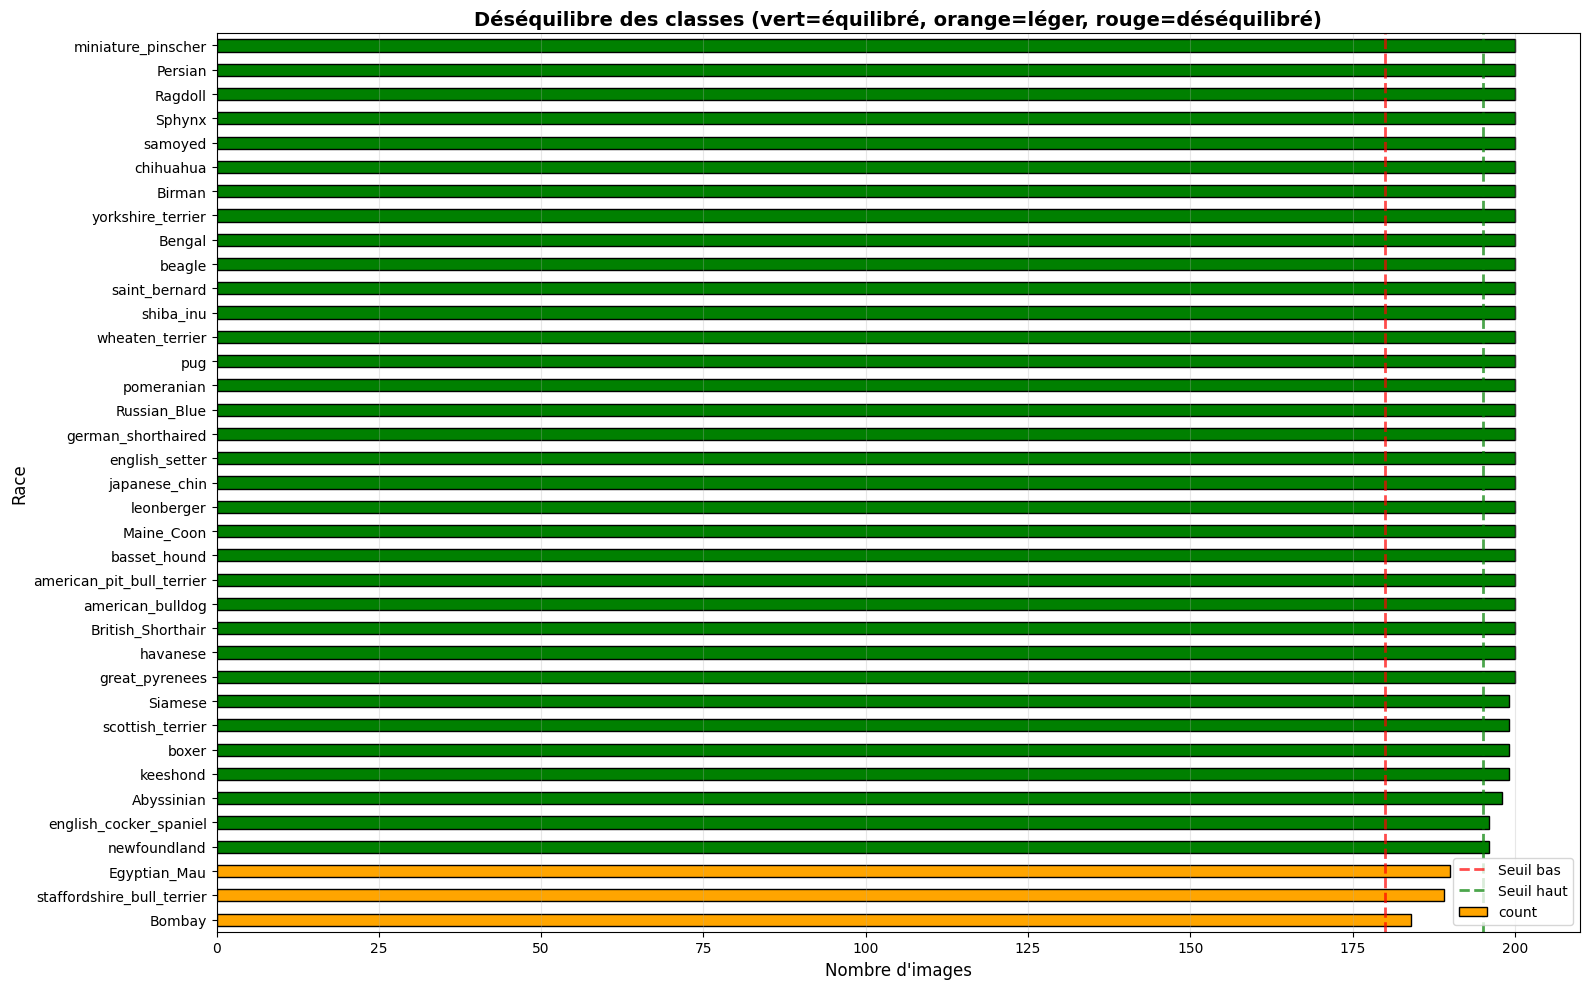

In [7]:
# Catégorisation
threshold_low = 180
threshold_high = 195

balanced = breed_counts[breed_counts >= threshold_high]
slightly_imbalanced = breed_counts[(breed_counts >= threshold_low) & (breed_counts < threshold_high)]
imbalanced = breed_counts[breed_counts < threshold_low]

print(f"Classes équilibrées (≥{threshold_high} images): {len(balanced)}")
print(f"Classes légèrement déséquilibrées ({threshold_low}-{threshold_high-1} images): {len(slightly_imbalanced)}")
print(f"Classes déséquilibrées (<{threshold_low} images): {len(imbalanced)}")

if len(imbalanced) > 0:
    print(f" Races les plus déséquilibrées:")
    print(imbalanced)

# Visualisation avec code couleur
fig, ax = plt.subplots(figsize=(16, 10))
colors_list = ['green' if x >= threshold_high else 'orange' if x >= threshold_low else 'red' 
               for x in breed_counts.sort_values()]
breed_counts.sort_values().plot(kind='barh', ax=ax, color=colors_list, edgecolor='black')
ax.set_title('Déséquilibre des classes (vert=équilibré, orange=léger, rouge=déséquilibré)', 
             fontsize=14, weight='bold')
ax.set_xlabel('Nombre d\'images', fontsize=12)
ax.set_ylabel('Race', fontsize=12)
ax.axvline(x=threshold_low, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Seuil bas')
ax.axvline(x=threshold_high, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Seuil haut')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### Répartition par race et par espèce


Nombre de races de chats: 12
Nombre de races de chiens: 25

Races de chats: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx']

Races de chiens: ['american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


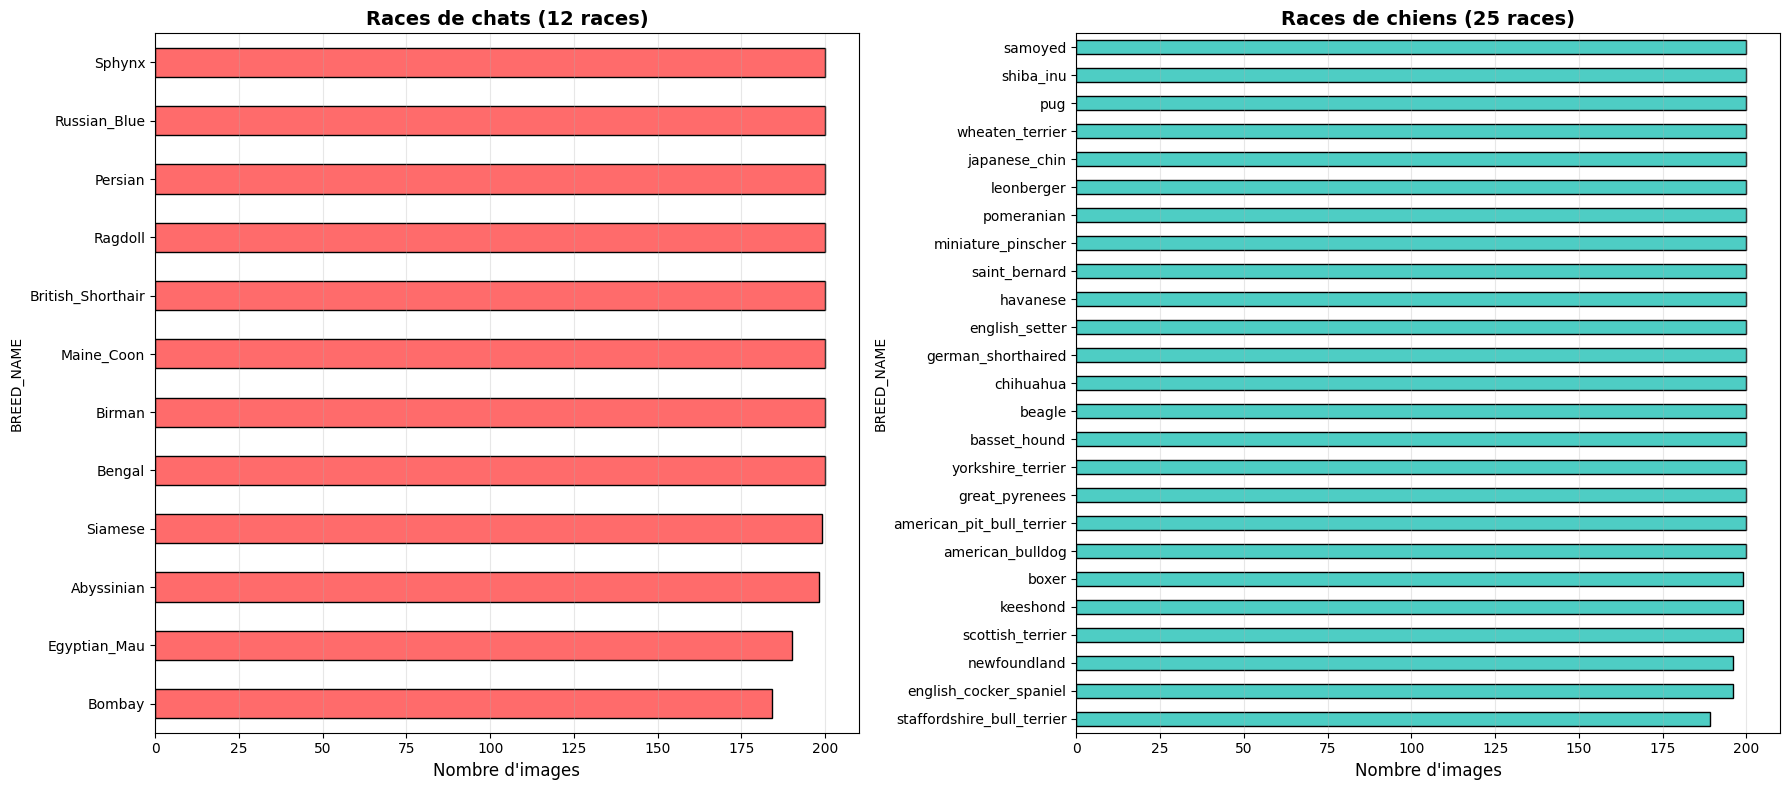

In [8]:
breed_species = df.groupby(['BREED_NAME', 'SPECIES_NAME']).size().reset_index(name='count')
cats_breeds = breed_species[breed_species['SPECIES_NAME'] == 'Cat']['BREED_NAME'].unique()
dogs_breeds = breed_species[breed_species['SPECIES_NAME'] == 'Dog']['BREED_NAME'].unique()

print(f"\nNombre de races de chats: {len(cats_breeds)}")
print(f"Nombre de races de chiens: {len(dogs_breeds)}")

print(f"\nRaces de chats: {sorted(cats_breeds)}")
print(f"\nRaces de chiens: {sorted(dogs_breeds)}")

# Visualisation séparée
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

cats_data = df[df['SPECIES_NAME'] == 'Cat']['BREED_NAME'].value_counts().sort_values()
dogs_data = df[df['SPECIES_NAME'] == 'Dog']['BREED_NAME'].value_counts().sort_values()

cats_data.plot(kind='barh', ax=axes[0], color='#FF6B6B', edgecolor='black')
axes[0].set_title(f'Races de chats ({len(cats_breeds)} races)', fontsize=14, weight='bold')
axes[0].set_xlabel('Nombre d\'images', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

dogs_data.plot(kind='barh', ax=axes[1], color='#4ECDC4', edgecolor='black')
axes[1].set_title(f'Races de chiens ({len(dogs_breeds)} races)', fontsize=14, weight='bold')
axes[1].set_xlabel('Nombre d\'images', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### Cohérence des masques de segmentation


Vérification en cours...
 Résultats (sur 100 images):
 Images présentes: 100/100 (100.0%)
 Masques présents: 100/100 (100.0%)
 Dimensions concordantes: 100/100 (100.0%)
 Masques valides (valeurs 1,2,3): 100/100 (100.0%)
  Visualisation d'exemples...
Visualisation des exemples terminée


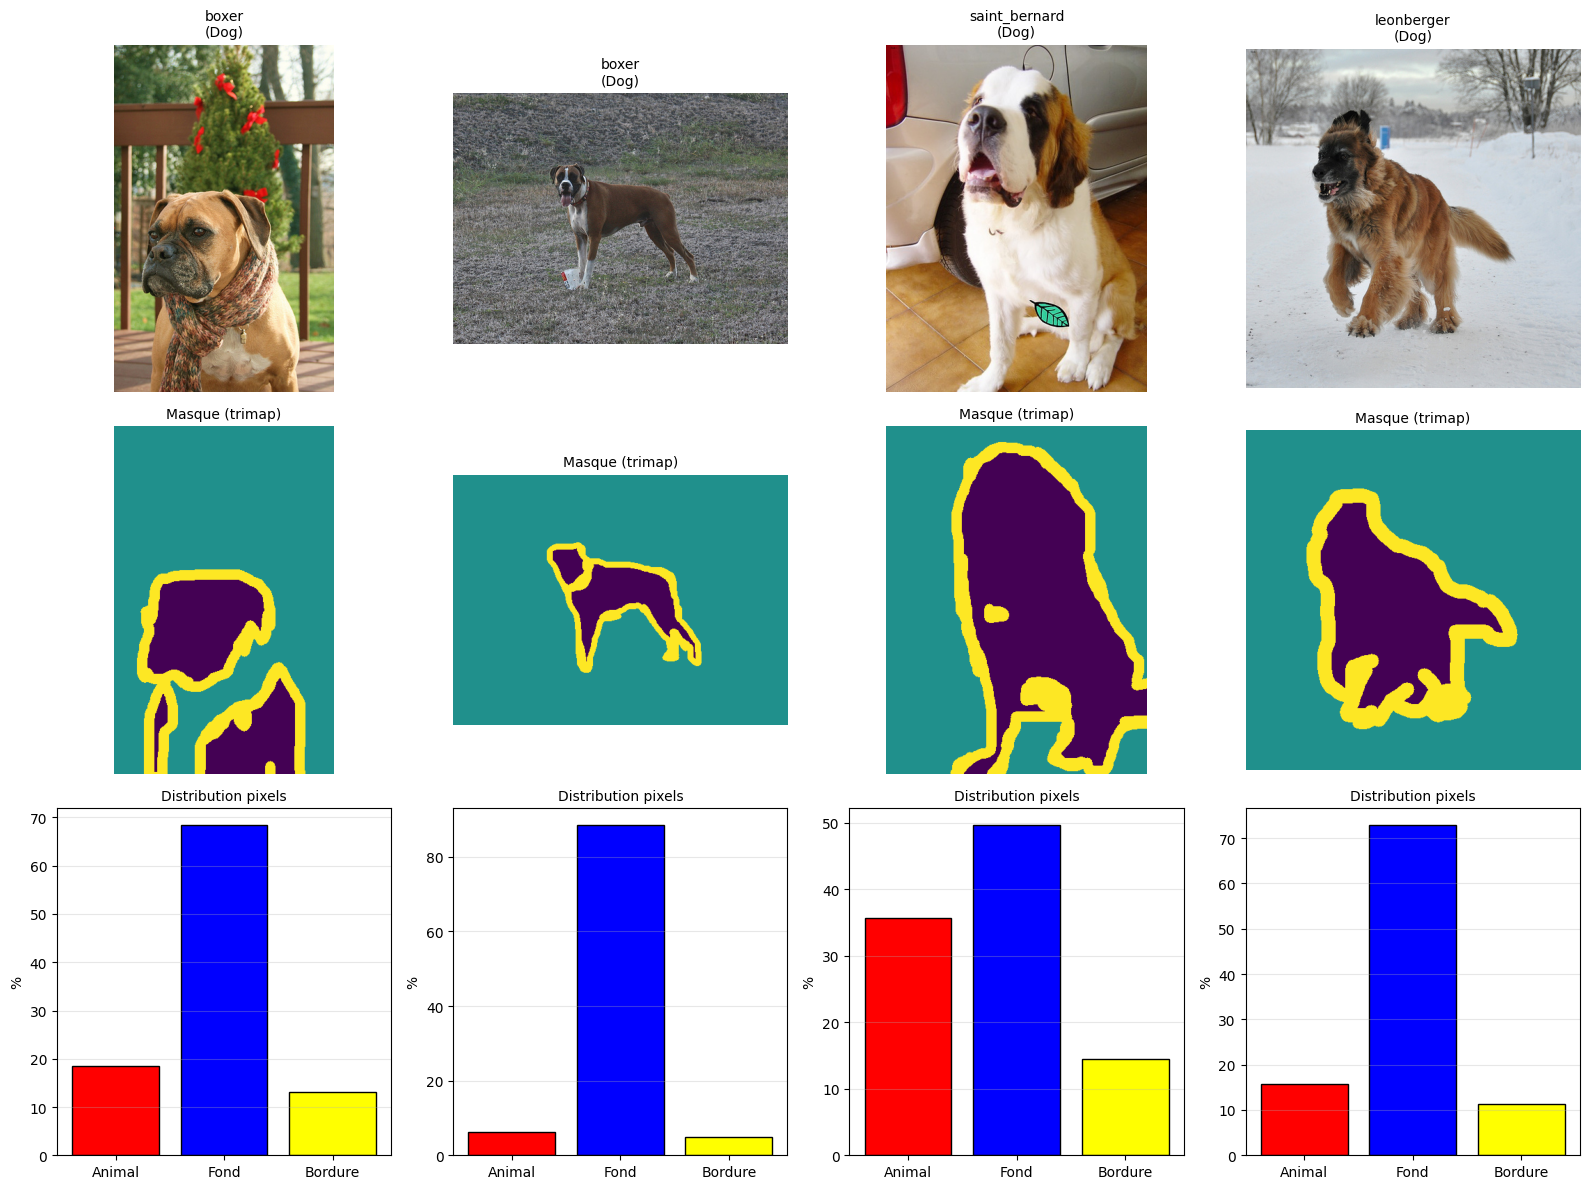

In [9]:
images_dir = "./oxford-iiit-pet/images"
masks_dir = "./oxford-iiit-pet/annotations/trimaps"

# Vérifier l'existence des fichiers
images_exist = []
masks_exist = []
dimensions_match = []
mask_quality = []

print("\nVérification en cours...")
sample_size = min(100, len(df))  # Échantillon pour test rapide

for idx, row in df.head(sample_size).iterrows():
    img_name = row['Image']
    mask_name = img_name.replace('.jpg', '.png')
    
    img_path = os.path.join(images_dir, img_name)
    mask_path = os.path.join(masks_dir, mask_name)
    
    img_exists = os.path.exists(img_path)
    mask_exists = os.path.exists(mask_path)
    
    images_exist.append(img_exists)
    masks_exist.append(mask_exists)
    
    if img_exists and mask_exists:
        img = Image.open(img_path)
        mask = Image.open(mask_path)
        dimensions_match.append(img.size == mask.size)
        
        # Vérifier valeurs du masque
        mask_array = np.array(mask)
        unique_vals = np.unique(mask_array)
        valid_mask = all(val in [1, 2, 3] for val in unique_vals)
        mask_quality.append(valid_mask)
    else:
        dimensions_match.append(False)
        mask_quality.append(False)

print(f" Résultats (sur {sample_size} images):")
print(f" Images présentes: {sum(images_exist)}/{sample_size} ({sum(images_exist)/sample_size*100:.1f}%)")
print(f" Masques présents: {sum(masks_exist)}/{sample_size} ({sum(masks_exist)/sample_size*100:.1f}%)")
print(f" Dimensions concordantes: {sum(dimensions_match)}/{sample_size} ({sum(dimensions_match)/sample_size*100:.1f}%)")
print(f" Masques valides (valeurs 1,2,3): {sum(mask_quality)}/{sample_size} ({sum(mask_quality)/sample_size*100:.1f}%)")

# Visualiser des exemples
print("  Visualisation d'exemples...")
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

sample_indices = rd.sample(range(len(df)), 4)

for i, idx in enumerate(sample_indices):
    row = df.iloc[idx]
    img_name = row['Image']
    mask_name = img_name.replace('.jpg', '.png')
    
    img_path = os.path.join(images_dir, img_name)
    mask_path = os.path.join(masks_dir, mask_name)
    
    if os.path.exists(img_path) and os.path.exists(mask_path):
        # Image originale
        img = Image.open(img_path)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"{row['BREED_NAME']}\n({row['SPECIES_NAME']})", fontsize=10)
        axes[0, i].axis('off')
        
        # Masque
        mask = np.array(Image.open(mask_path))
        axes[1, i].imshow(mask, cmap='viridis')
        axes[1, i].set_title('Masque (trimap)', fontsize=10)
        axes[1, i].axis('off')
        
        # Statistiques du masque
        unique, counts = np.unique(mask, return_counts=True)
        props = counts / mask.size * 100
        axes[2, i].bar(['Animal', 'Fond', 'Bordure'], props, 
                      color=['red', 'blue', 'yellow'], edgecolor='black')
        axes[2, i].set_ylabel('%')
        axes[2, i].set_title('Distribution pixels', fontsize=10)
        axes[2, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
print("Visualisation des exemples terminée")
plt.show()

ANALYSE À FAIRE ==> LA NEIGE COMPLIQUÉ A VISUALISER MASQUE PAS FOU

### Classification binaire

On importe les données

In [5]:

base_path = "./oxford-iiit-pet/"
img_dir = os.path.join(base_path, "images/")
mask_dir = os.path.join(base_path, "annotations/trimaps/")



df['mask_filename'] = df['Image'].str.replace('.jpg', '.png')



# --- Division du Dataset (Train / Val / Test) ---
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['SPECIES_NAME'])
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['SPECIES_NAME'])

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

Train: 4703 | Validation: 1176 | Test: 1470


In [6]:
batch_size = 20  # doit être un diviseur de N_train and N_validation (20 est bien un diviseur de 5200 et 1000, c'est pour ça qu'on a pris des valeurs rondes pour N_train et N_validation)
img_width = 150
img_height = 150

# Training images
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    img_dir,
    x_col = 'Image',
    y_col = 'SPECIES_NAME',
    target_size = (img_width, img_height),
    class_mode = 'binary',
    batch_size = batch_size
)

# Validation images
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_dataframe(
    val_df,
    img_dir,
    x_col = 'Image',
    y_col = 'SPECIES_NAME',
    class_mode = 'binary',
    target_size = (img_width, img_height),
    batch_size = batch_size
)

# Test images
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    img_dir,
    x_col = 'Image',
    y_col = 'SPECIES_NAME',
    class_mode = 'binary',
    target_size = (img_width, img_height),
    batch_size = batch_size)

Found 4703 validated image filenames belonging to 2 classes.
Found 1176 validated image filenames belonging to 2 classes.
Found 1470 validated image filenames belonging to 2 classes.


Ce code configure le pipeline de préparation des données pour la classification binaire (Chats vs Chiens). Il définit d'abord les hyperparamètres structurels, fixant la résolution des images à 150×150 pixels et la taille des lots (batch_size) à 20, une valeur choisie pour diviser exactement le nombre total d'échantillons. Trois instances d'ImageDataGenerator sont ensuite créées pour les ensembles d'entraînement, de validation et de test, appliquant uniquement une normalisation des pixels (rescale=1./255) pour ramener leurs valeurs dans l'intervalle [0,1]. La méthode flow_from_dataframe est utilisée pour générer les flux de données en associant les fichiers images du répertoire img_dir (colonne 'Image') à leurs étiquettes cibles (colonne 'SPECIES_NAME'). Enfin, le paramètre class_mode='binary' est spécifié pour encoder les étiquettes en format binaire, adaptant ainsi les données à une sortie à deux classes.

### CNN Simple

In [12]:
def cnn_simple(nom):
    # Initialisation du modèle Séquentiel (les couches s'empilent les unes après les autres)
    cnn = Sequential(name=nom)
    cnn.add(Input(shape=(img_width,img_height,3)))

    cnn.add(Conv2D(32, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(64, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(96, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    #cnn_simple.add(Conv2D(128, (3,3), activation='relu'))
    #cnn_simple.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Flatten())
    # cnn_simple.add(Dense(512, activation='relu'))
    cnn.add(Dense(64, activation='relu'))
    #cnn_simple.add(Dropout(0.5))
    cnn.add(Dense(1, activation='sigmoid'))

    
    return cnn

In [13]:
cnn_naif=cnn_simple("cnn_simple")
cnn_naif.summary()        

I0000 00:00:1768811188.296170   27215 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13692 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation, pci bus id: 0000:55:00.0, compute capability: 8.9


Model: "cnn_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,775,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,850,529 (7.06 MB)

 Trainable params: 1,850,529 (7.06 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def Entrainement(cnn,train_generator, epochs=10, learn_rate = 3e-4):
    print("Entrainement de ",cnn.name)
    cnn.compile(
        loss = 'binary_crossentropy',
        optimizer = Adam(learning_rate=learn_rate),
        metrics = ['accuracy'])

    t_learning_cnn = time.time()
    
    cnn_history = cnn.fit(
        train_generator,
        validation_data = val_generator,
        epochs = epochs
    )
    
    t_learning_cnn = time.time() - t_learning_cnn
    print("Learning time for %d epochs : %d seconds" % (epochs, t_learning_cnn))
    
    return t_learning_cnn, cnn_history

In [15]:
t_learning_cnn_naif, cnn_naif_history = Entrainement(cnn_naif,train_generator)

Entrainement de  cnn_simple
Epoch 1/10


2026-01-19 09:26:29.983439: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ef1780180e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-19 09:26:29.983459: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX 2000 Ada Generation, Compute Capability 8.9
2026-01-19 09:26:30.008260: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-19 09:26:30.200605: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-01-19 09:26:30.661201: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_259', 8 bytes spill stores, 8 bytes spill loads



  5/236 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.5225 - loss: 0.6718

I0000 00:00:1768811192.879107   28062 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


142/236 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.6681 - loss: 0.6272

2026-01-19 09:26:40.269970: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_588', 4 bytes spill stores, 4 bytes spill loads



236/236 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - accuracy: 0.6838 - loss: 0.5940 - val_accuracy: 0.7406 - val_loss: 0.5399
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.7408 - loss: 0.5189 - val_accuracy: 0.7755 - val_loss: 0.4989
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.7765 - loss: 0.4716 - val_accuracy: 0.7704 - val_loss: 0.4491
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.8061 - loss: 0.4269 - val_accuracy: 0.8053 - val_loss: 0.4322
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.8358 - loss: 0.3819 - val_accuracy: 0.8112 - val_loss: 0.4160
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.8580 - loss: 0.3365 - val_accuracy: 0.8002 - val_loss: 0.4354
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.8756 - loss: 0.2943 - val_accuracy: 0.7798 - val_loss: 0.5162
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.8967 - loss: 0.2465 - val_accurac

In [16]:

def plot_training_analysis(history):
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', linestyle="--",label='Training accuracy')
    plt.plot(epochs, val_acc, 'g', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', linestyle="--",label='Training loss')
    plt.plot(epochs, val_loss,'g', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

def Analyse_resultats(cnn,cnn_history):
    t_prediction_cnn = time.time()
    score_cnn_train = cnn.evaluate(train_generator, verbose=1)
    score_cnn_validation = cnn.evaluate(val_generator, verbose=1)

    t_prediction_cnn = time.time() - t_prediction_cnn

    print('Train accuracy:', score_cnn_train[1])
    print('Validation accuracy:', score_cnn_validation[1])
    print("Time Prediction: %.2f seconds" % t_prediction_cnn)

    plot_training_analysis(cnn_history)
    return t_prediction_cnn

236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9636 - loss: 0.1171
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.7840 - loss: 0.5318
Train accuracy: 0.9636402130126953
Validation accuracy: 0.7840136289596558
Time Prediction: 16.56 seconds


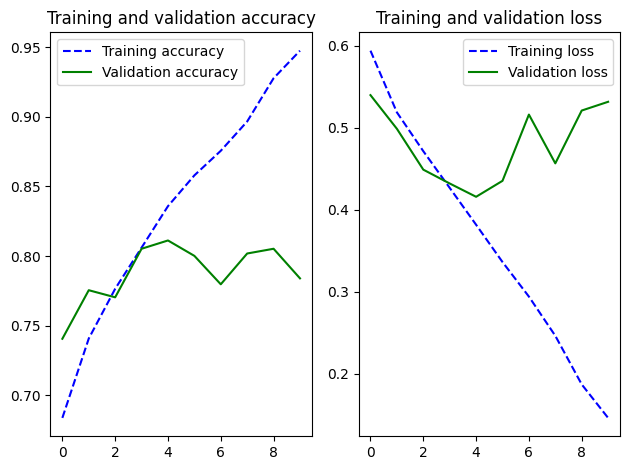

In [17]:
t_prediction_cnn_naif = Analyse_resultats(cnn_naif,cnn_naif_history)

train loss << val_loss  ==> overfitting ==> on va donc faire du dropout 


DROPOUT

In [18]:
def cnn_simple(nom):
    # Initialisation du modèle Séquentiel (les couches s'empilent les unes après les autres)
    cnn = Sequential(name=nom)
    cnn.add(Input(shape=(img_width,img_height,3)))

    cnn.add(Conv2D(32, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(64, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(96, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    #cnn_simple.add(Conv2D(128, (3,3), activation='relu'))
    #cnn_simple.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Flatten())
    # cnn_simple.add(Dense(512, activation='relu'))
    cnn.add(Dense(64, activation='relu'))
    cnn.add(Dropout(0.5))
    cnn.add(Dense(1, activation='sigmoid'))

    
    return cnn

In [19]:
cnn_naif_dropout=cnn_simple("cnn_simple_dropout")
cnn_naif_dropout.summary() 

Model: "cnn_simple_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,775,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,850,529 (7.06 MB)

 Trainable params: 1,850,529 (7.06 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
t_learning_cnn_naif_dropout, cnn_naif_dropout_history = Entrainement(cnn_naif_dropout,train_generator)

Entrainement de  cnn_simple_dropout
Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.6757 - loss: 0.6064 - val_accuracy: 0.6777 - val_loss: 0.5507
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.6862 - loss: 0.5625 - val_accuracy: 0.6922 - val_loss: 0.5230
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.7280 - loss: 0.5308 - val_accuracy: 0.7653 - val_loss: 0.5051
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.7623 - loss: 0.4988 - val_accuracy: 0.7934 - val_loss: 0.4718
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.7818 - loss: 0.4637 - val_accuracy: 0.8044 - val_loss: 0.4385
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.8042 - loss: 0.4327 - val_accuracy: 0.8163 - val_loss: 0.4279
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.8267 - loss: 0.3908 - val_accuracy: 0.8121 - val_loss: 0.4268
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step 

236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9179 - loss: 0.2151
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8197 - loss: 0.4262
Train accuracy: 0.917924702167511
Validation accuracy: 0.819727897644043
Time Prediction: 17.00 seconds


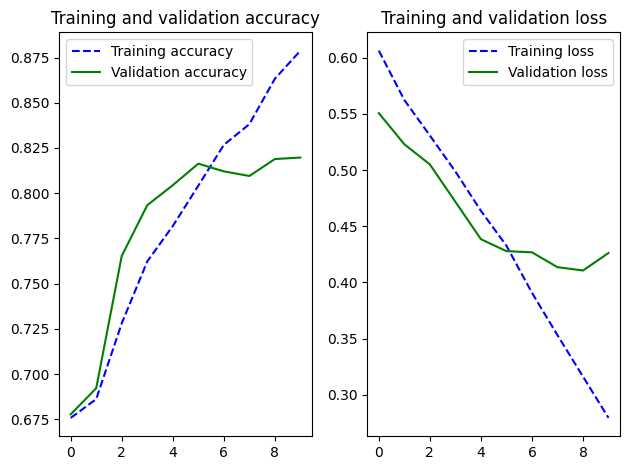

In [21]:
t_prediction_cnn_naif_dropout = Analyse_resultats(cnn_naif_dropout,cnn_naif_dropout_history)

### Amélioration 

### data augmentation

Définition : Technique consistant à créer des variantes artificielles des données d'entraînement (rotations, zooms, modifications de luminosité, etc.).

Objectif principal : Lutter contre le surapprentissage (overfitting) en augmentant artificiellement la taille du jeu de données.

Bénéfice : Améliore la robustesse et la capacité de généralisation du modèle en lui apprenant à ignorer les variations non pertinentes (ex: l'orientation d'un objet).

Application : Essentielle lorsque les données réelles sont limitées ou coûteuses à obtenir.

In [22]:
# Générateur avec Augmentation (Rotation, Zoom, Flip...)
aug_datagen = ImageDataGenerator(
    rotation_range = 10,
    rescale = 1./255,
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    shear_range = 0.1,
    zoom_range = 0.1,
    brightness_range=[0.9,1.1], 
    channel_shift_range=10, 
    horizontal_flip = True,
    fill_mode='nearest'
)

# Seul le train est augmenté ! Val et Test restent "normaux"
train_gen_aug = aug_datagen.flow_from_dataframe(
    train_df, directory=img_dir, x_col='Image', y_col='SPECIES_NAME',
   target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary' 
)

# On réutilise le même modèle, mais entraîné sur des données augmentées
cnn_aug = cnn_simple("cnn_augmente")
temps_aug,history_aug = Entrainement(
    cnn_aug, 
    train_gen_aug,  
    epochs=30,  
    learn_rate=3e-4
)



Found 4703 validated image filenames belonging to 2 classes.
Entrainement de  cnn_augmente
Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - accuracy: 0.6736 - loss: 0.6216 - val_accuracy: 0.6777 - val_loss: 0.5896
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.6887 - loss: 0.5685 - val_accuracy: 0.7151 - val_loss: 0.5296
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - accuracy: 0.7159 - loss: 0.5484 - val_accuracy: 0.7058 - val_loss: 0.5421
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.7289 - loss: 0.5334 - val_accuracy: 0.7696 - val_loss: 0.4864
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - accuracy: 0.7516 - loss: 0.5133 - val_accuracy: 0.7687 - val_loss: 0.4686
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - accuracy: 0.7578 - loss: 0.5025 - val_accuracy: 0.7840 - val_loss: 0.4535
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - accuracy: 0.7661 - loss: 0.4859 - val_accuracy: 0.8078 - val_loss:

236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.9045 - loss: 0.2241
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8605 - loss: 0.3307
Train accuracy: 0.9045290350914001
Validation accuracy: 0.8605442047119141
Time Prediction: 18.91 seconds


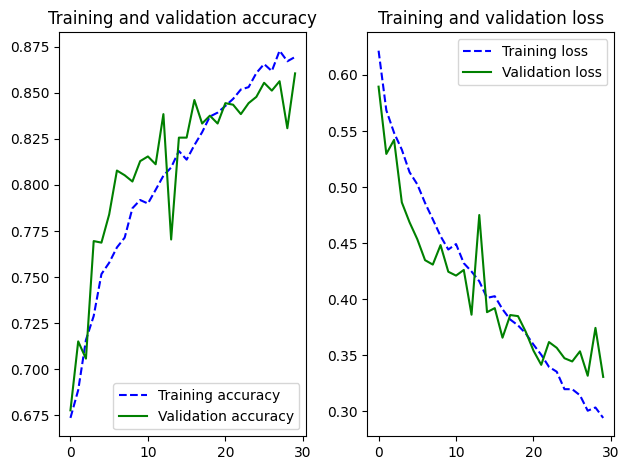

In [23]:
temps_prediction = Analyse_resultats(cnn_aug, history_aug)

Conclusion sur les premiers résultats et transition vers le Transfer Learning

Malgré la mise en place de stratégies de régularisation rigoureuses qui nous ont permi de limiter l'overfitting, notamment via la Data Augmentation (pour diversifier mon jeu de données) et l'ajout de couches Dropout (pour forcer le réseau à la robustesse), les performances de notre modèle restent insuffisantes. La loss stagne à un niveau trop élevé, ce qui indique que le problème ne vient plus uniquement du surapprentissage, mais probablement de la capacité limitée de l'architecture actuelle à extraire des caractéristiques pertinentes.

C'est pourquoi nous décidons de nous tourner vers une approche par Transfer Learning en utilisant le modèle pré-entraîné VGG16 pour les raisons suivantes :

- Au lieu de laisser notre modèle apprendre péniblement à reconnaître des formes basiques (bords, textures, contrastes), on utilise les poids optimisés de VGG16 sur ImageNet. Cela permet de bénéficier d'extracteurs de caractéristiques extrêmement performants dès le premier tour d'entraînement.

- Résolution du problème de convergence : VGG16, grâce à son architecture profonde et ses filtres déjà formés, offre un point de départ bien plus proche de la solution optimale, ce qui devrait mécaniquement faire chuter la loss.

- Optimisation de la capacité d'apprentissage : Tandis que nos efforts précédents (Dropout/Augmentation) visaient à limiter la mémorisation, l'utilisation de VGG16 vise à augmenter la qualité de la compréhension visuelle.

### Pre-trained Network

In [24]:

def plot_training_analysis(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', linestyle="--",label='Training accuracy')
    plt.plot(epochs, val_acc, 'g', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', linestyle="--",label='Training loss')
    plt.plot(epochs, val_loss,'g', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 37s 149ms/step - accuracy: 0.8484 - loss: 0.3440 - val_accuracy: 0.8588 - val_loss: 0.3346
Epoch 2/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 129ms/step - accuracy: 0.8920 - loss: 0.2494 - val_accuracy: 0.9090 - val_loss: 0.2177
Epoch 3/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.8992 - loss: 0.2391 - val_accuracy: 0.9099 - val_loss: 0.2165
Epoch 4/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - accuracy: 0.9054 - loss: 0.2179 - val_accuracy: 0.9158 - val_loss: 0.2056
Epoch 5/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 32s 137ms/step - accuracy: 0.9247 - loss: 0.1784 - val_accuracy: 0.9260 - val_loss: 0.1960
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 121ms/step - accuracy: 0.9424 - loss: 0.1468
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9260 - loss: 0.1960
Train accuracy: 0.9423772096633911
Validation accuracy: 0.9260203838348389
Time Prediction: 32.43 seconds


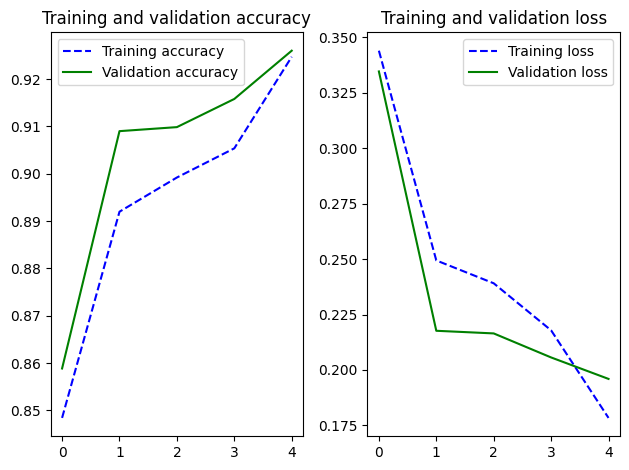

In [28]:
conv_base = VGG16(
    weights = 'imagenet', # We use the network weights already pre-trained on the ImageNet database.
    include_top = False,  # The Dense part of the original network is not retained
    input_shape = (img_width, img_height, 3)
)

conv_base.summary()

#train_features = conv_base.predict(train_gen_aug)
#train_features = np.reshape(train_features,(train_features.shape[0], -1))

#validation_features = conv_base.predict(val_generator)
#validation_features = np.reshape(validation_features,(validation_features.shape[0], -1))

#train_data = train_df.to_numpy()
#y_train = np.array([int(numeric_string) for numeric_string in train_data[:,2]]) -1

#validation_data = val_df.to_numpy()
#y_validation = np.array([int(numeric_string) for numeric_string in validation_data[:,2]]) -1

#y_train = train_df['SPECIES'].values - 1  


#y_validation = val_df['SPECIES'].values - 1

# Construction de la tête de classification
vgg_combined= Sequential()
vgg_combined.add(Input(shape=(img_width, img_height, 3)))
vgg_combined.add(conv_base)
vgg_combined.add(Flatten())
vgg_combined.add(Dense(256, activation='relu'))
#vgg_combined.add(Dropout(0.5))
vgg_combined.add(Dense(1, activation='sigmoid'))

conv_base.trainable=False

vgg_combined.summary()

# Compilation
epochs = 5
vgg_combined.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

# Entraînement

t_learning_vgg_combined = time.time()

vgg_combined_history = vgg_combined.fit(
    train_gen_aug, 
    validation_data= val_generator,
    epochs=epochs,
)
t_prediction_vgg_combined = time.time()

score_vgg_combined_train = vgg_combined.evaluate(train_gen_aug)
score_vgg_combined_validation = vgg_combined.evaluate(val_generator)

t_prediction_vgg_combined = time.time() - t_prediction_vgg_combined

print('Train accuracy:', score_vgg_combined_train[1])
print('Validation accuracy:', score_vgg_combined_validation[1])
print("Time Prediction: %.2f seconds" % t_prediction_vgg_combined )
plot_training_analysis(vgg_combined_history)

L'utilisation de VGG16 permet de bénéficier immédiatement de filtres visuels complexes (détection de textures, formes, contours) appris sur ImageNet. En injectant la Data Augmentation en amont de ce réseau, nous forçons le classifieur final (la tête dense) à devenir invariant aux transformations géométriques. Le modèle n'apprend plus à reconnaître un chat uniquement dans une position statique, mais apprend à identifier les caractéristiques d'un chat (oreilles, museau) indépendamment du zoom, de la rotation ou du cadrage de l'image.

Le principal défi des réseaux profonds est le sur-apprentissage (overfitting), où le modèle mémorise le bruit des données d'entraînement. En modifiant aléatoirement les images à chaque époque via le générateur, nous simulons un jeu de données virtuellement infini. Cela oblige le modèle à généraliser plutôt qu'à mémoriser, garantissant ainsi que les performances observées sur le jeu de validation reflètent une réelle capacité à traiter des données inconnues.

Bien que le modèle actuel soit performant, il reste limité par le fait que la base VGG16 est "figée" sur ses connaissances d'origine (ImageNet). Le passage au Fine-Tuning (affinement) est l'évolution logique pour maximiser la précision :

- Actuellement, VGG16 extrait des caractéristiques génériques utiles pour 1000 classes d'objets (voitures, fruits, animaux, etc.). En "dégelant" les dernières couches convolutionnelles, nous permettons au réseau d'adapter ses filtres les plus profonds spécifiquement aux spécificités morphologiques des chats et des chiens du dataset Oxford.

- Le Fine-Tuning permet de passer d'une reconnaissance basée sur des formes globales à une reconnaissance de détails subtils propres aux races présentes dans le dataset. Cela permet souvent de corriger les erreurs résiduelles sur les cas difficiles (images ambiguës ou de mauvaise qualité) que l'extracteur générique ne parvenait pas à discriminer parfaitement.

### FINE TUNING 

In [29]:
conv_base.trainable = True

for layer in conv_base.layers[:15]:
    layer.trainable = False

vgg_combined.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,007,685 (80.14 MB)

 Trainable params: 9,177,089 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 4,195,332 (16.00 MB)

In [34]:
epochs = 10

vgg_combined.compile(
    loss = 'binary_crossentropy',
    optimizer = Adam(learning_rate=1e-4), # Reduced learning rates to avoid smashing everything and risking overfitting
    metrics = ['accuracy']
)

t_learning_vgg_combined_tuned = time.time()
vgg_combined_tuned_history = vgg_combined.fit(
    train_gen_aug,
    validation_data = val_generator,
    epochs = epochs
)
t_learning_vgg_combined_tuned = time.time() - t_learning_vgg_combined_tuned

print("Learning time for %d epochs : %d seconds" % (epochs, t_learning_vgg_combined_tuned))

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.9724 - loss: 0.0764 - val_accuracy: 0.9311 - val_loss: 0.1897
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 121ms/step - accuracy: 0.9798 - loss: 0.0521 - val_accuracy: 0.9354 - val_loss: 0.1765
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.9838 - loss: 0.0439 - val_accuracy: 0.9558 - val_loss: 0.1268
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - accuracy: 0.9858 - loss: 0.0393 - val_accuracy: 0.9515 - val_loss: 0.1205
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 32s 133ms/step - accuracy: 0.9902 - loss: 0.0307 - val_accuracy: 0.9124 - val_loss: 0.3627
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 32s 136ms/step - accuracy: 0.9858 - loss: 0.0417 - val_accuracy: 0.9396 - val_loss: 0.2168
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 129ms/step - accuracy: 0.9911 - loss: 0.0225 - val_accuracy: 0.9600 - val_loss: 0.1496
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 31s 131ms/step - accuracy: 0.9921 - loss: 0

236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.9783 - loss: 0.0556
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9201 - loss: 0.1948
Train accuracy: 0.9783117175102234
Validation accuracy: 0.9200680255889893
Time Prediction: 33.52 seconds


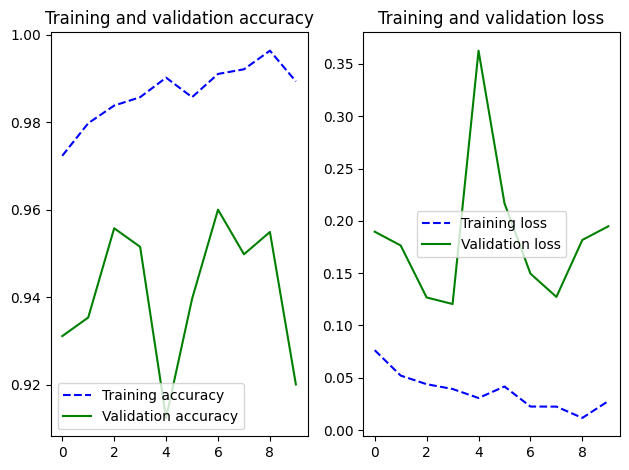

In [35]:
t_prediction_vgg_combined_tuned = time.time()

score_vgg_combined_tuned_train = vgg_combined.evaluate(train_gen_aug)
score_vgg_combined_tuned_validation = vgg_combined.evaluate(val_generator)

t_prediction_vgg_combined_tuned = time.time() - t_prediction_vgg_combined_tuned

print('Train accuracy:', score_vgg_combined_tuned_train[1])
print('Validation accuracy:', score_vgg_combined_tuned_validation[1])
print("Time Prediction: %.2f seconds" % t_prediction_vgg_combined_tuned )
plot_training_analysis(vgg_combined_tuned_history)

On observe un début de sur-apprentissage (overfitting). Bien que la précision de validation soit excellente (autour de 95%), la courbe de perte (Loss) de validation montre une instabilité et diverge de la perte d'entraînement. Le modèle est deux fois plus 'confiant' sur les données d'entraînement (loss ~0.06) que sur la validation (loss ~0.12), ce qui indique qu'il commence à mémoriser les spécificités du jeu d'entraînement. On va rajouter du dropout afin de limiter le surapprentissage. 

precision au max => on va faire sur le test maintenant

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step


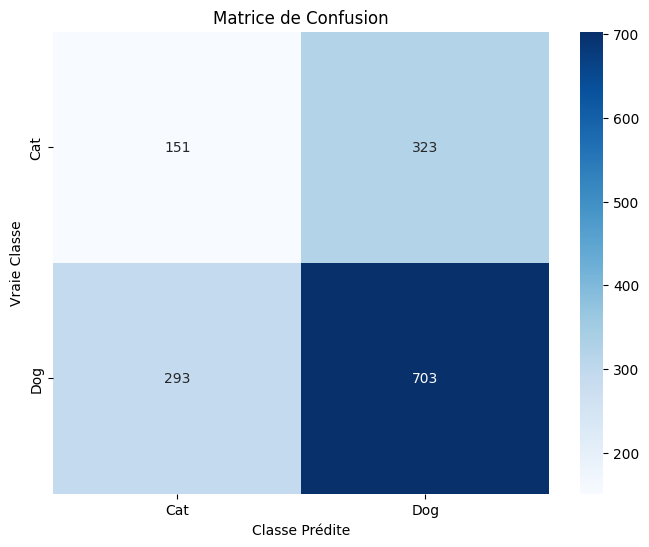


=== Rapport de Classification ===
              precision    recall  f1-score   support

         Cat       0.34      0.32      0.33       474
         Dog       0.69      0.71      0.70       996

    accuracy                           0.58      1470
   macro avg       0.51      0.51      0.51      1470
weighted avg       0.57      0.58      0.58      1470



In [55]:
test_generator.reset()
predictions = vgg_combined_fine_plus.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Vraies classes
true_classes = test_generator.classes

# Matrice de confusion
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cat', 'Dog'], 
            yticklabels=['Cat', 'Dog'])
plt.title('Matrice de Confusion')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

# Rapport détaillé
print("\n=== Rapport de Classification ===")
print(classification_report(true_classes, predicted_classes, 
                          target_names=['Cat', 'Dog']))

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step
Nombre d'erreurs : 652 / 1470


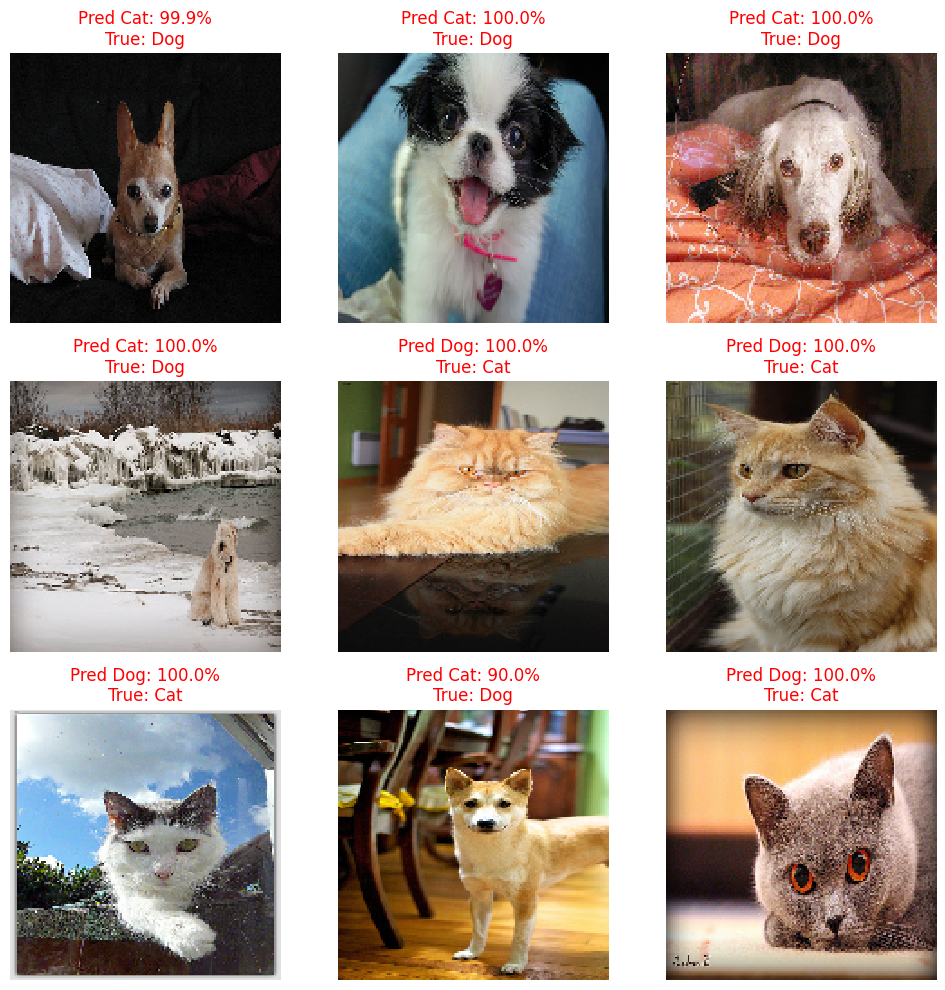

In [57]:
test_preds = vgg_combined_fine_plus.predict(test_generator)
y_true = test_generator.classes  # classes réelles
y_pred = (test_preds > 0.5).astype(int).flatten()  # prédictions binaires

# Identifier les erreurs
error_idx = np.where(y_true != y_pred)[0]
print(f"Nombre d'erreurs : {len(error_idx)} / {len(y_true)}")

# Visualiser quelques erreurs
n_errors_to_show = min(9, len(error_idx))
selected_errors = np.random.choice(error_idx, size=n_errors_to_show, replace=False)

fig = plt.figure(figsize=(10,10))

for i, idx in enumerate(selected_errors):
    # Charger l'image
    img = img_to_array(load_img(test_generator.filepaths[idx], target_size=(img_width, img_height)))/255
    
    pred_prob = test_preds[idx][0]
    
    ax = fig.add_subplot(3,3,i+1)
    ax.imshow(img, interpolation='nearest')
    
    # Déterminer le titre et la couleur
    if pred_prob > 0.5:
        title = f"Pred Dog: {pred_prob*100:.1f}%\nTrue: {'Dog' if y_true[idx]==1 else 'Cat'}"
        color = "red" if y_true[idx]==0 else "green"
    else:
        title = f"Pred Cat: {(1-pred_prob)*100:.1f}%\nTrue: {'Cat' if y_true[idx]==0 else 'Dog'}"
        color = "red" if y_true[idx]==1 else "green"
    
    ax.set_title(title, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()


# Classification fine

### Echantillons

La stratification par race permet d’éviter qu’une race apparaisse uniquement dans l’ensemble d’entraînement ou de test, ce qui biaiserait l’évaluation du modèle.

In [8]:
# On sépare le dataset en Train / Validation / Test
# Ici, on stratifie selon la race (BREED_NAME) pour
# s'assurer que chaque race est bien représentée
# dans tous les sous-ensembles.

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['BREED_NAME']
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['BREED_NAME']
)

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")
print("Nombre de races:", train_df["BREED_NAME"].nunique())


Train: 4703 | Validation: 1176 | Test: 1470
Nombre de races: 37


Le mode categorical transforme automatiquement les labels en vecteurs one-hot de taille 37.
Cela impose l’utilisation d’une activation softmax et de la fonction de perte categorical cross-entropy. (d'ou le fait QUE ON RE SCAKLE)

In [11]:
# Paramètres généraux
batch_size = 20
img_height = 150
img_width = 150

# Générateur d'entraînement
# On applique un rescaling pour normaliser les pixels entre 0 et 1
train_datagen = ImageDataGenerator(rescale=1./255)

# Générateur validation et test (sans augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Chargement des images d'entraînement
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',          # la cible est maintenant la race
    target_size=(img_height, img_width),
    class_mode='categorical',    # multi-classe → one-hot encoding
    batch_size=batch_size,
    shuffle=True #Éviter d’apprendre l’ordre des données
)

# Validation
val_generator = val_datagen.flow_from_dataframe(
    val_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_height, img_width),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

# Test
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_height, img_width),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

num_classes = len(train_generator.class_indices) #SERT À COco le nombre de classe pour la soltmax
print("Nombre de classes:", num_classes)



Found 4703 validated image filenames belonging to 37 classes.
Found 1176 validated image filenames belonging to 37 classes.
Found 1470 validated image filenames belonging to 37 classes.
Nombre de classes: 37


### Modèle CNN (sans dropout)

Sans dropout, le modèle apprend très bien sur les données d’entraînement mais a tendance à surapprendre, ce qui se traduit par une baisse ou une stagnation de la précision sur l’ensemble de validation.

In [13]:
def cnn_simple_multiclass(nom, num_classes):
    # Même idée que ton cnn_simple binaire, mais sortie multi-classe
    cnn = Sequential(name=nom)
    cnn.add(Input(shape=(img_width, img_height, 3)))

    cnn.add(Conv2D(32, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(64, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(96, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Flatten())
    cnn.add(Dense(64, activation='relu'))

    # IMPORTANT : en multi-classe => num_classes neurones + softmax
    cnn.add(Dense(num_classes, activation='softmax'))

    return cnn


In [14]:
def Entrainement_multiclass(cnn, train_generator, val_generator, epochs=10, learn_rate=3e-4):
    print("Entrainement de", cnn.name)

    # En multi-classe avec one-hot => categorical_crossentropy
    cnn.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learn_rate),
        metrics=['accuracy']
    )

    t_learning_cnn = time.time()

    cnn_history = cnn.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs
    )

    t_learning_cnn = time.time() - t_learning_cnn
    print("Learning time for %d epochs : %d seconds" % (epochs, t_learning_cnn))

    return t_learning_cnn, cnn_history


In [15]:
def plot_training_analysis(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', linestyle="--", label='Training accuracy')
    plt.plot(epochs, val_acc, 'g', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', linestyle="--", label='Training loss')
    plt.plot(epochs, val_loss, 'g', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [16]:
def Analyse_resultats_multiclass(cnn, train_generator, val_generator, cnn_history):

    t_prediction_cnn = time.time()

    score_cnn_train = cnn.evaluate(train_generator, verbose=1)
    score_cnn_validation = cnn.evaluate(val_generator, verbose=1)

    t_prediction_cnn = time.time() - t_prediction_cnn

    print('Train accuracy:', score_cnn_train[1])
    print('Validation accuracy:', score_cnn_validation[1])
    print("Time Prediction: %.2f seconds" % t_prediction_cnn)

    plot_training_analysis(cnn_history)

    return t_prediction_cnn


Model: "cnn_multiclass_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,775,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,852,869 (7.07 MB)

 Trainable params: 1,852,869 (7.07 MB)

 Non-trainable params: 0 (0.00 B)

Entrainement de cnn_multiclass_simple
Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.0336 - loss: 3.6156 - val_accuracy: 0.0391 - val_loss: 3.5867
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.0632 - loss: 3.5336 - val_accuracy: 0.0884 - val_loss: 3.4572
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.1237 - loss: 3.2824 - val_accuracy: 0.1114 - val_loss: 3.2951
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.2044 - loss: 2.8953 - val_accuracy: 0.1327 - val_loss: 3.1354
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.2874 - loss: 2.5379 - val_accuracy: 0.1616 - val_loss: 3.1350
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.3960 - loss: 2.1113 - val_accuracy: 0.1582 - val_loss: 3.3212
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.5386 - loss: 1.6284 - val_accuracy: 0.1794 - val_loss: 3.5461
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/ste

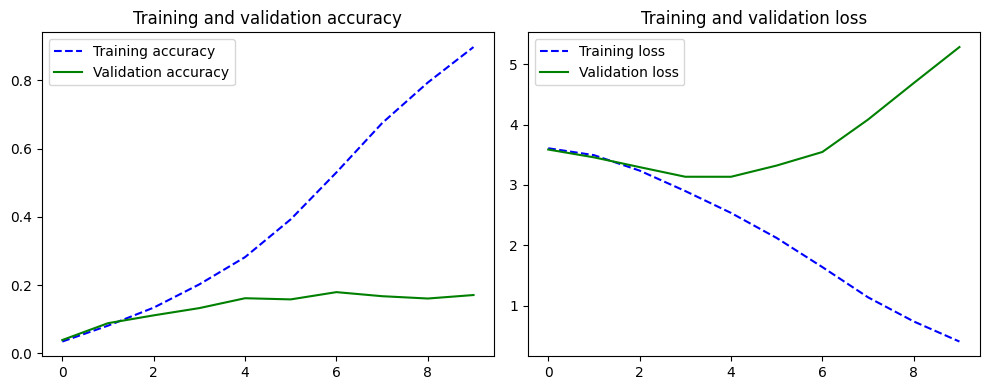

In [17]:
# Nombre de classes (races)
num_classes = len(train_generator.class_indices)

# Création du modèle multi-classe
cnn_mc_naif = cnn_simple_multiclass("cnn_multiclass_simple", num_classes)
cnn_mc_naif.summary()

# Entrainement
t_learning_cnn_mc_naif, cnn_mc_naif_history = Entrainement_multiclass(
    cnn_mc_naif,
    train_generator,
    val_generator,
    epochs=10,
    learn_rate=3e-4
)

# Analyse
t_prediction_cnn_mc_naif = Analyse_resultats_multiclass(
    cnn_mc_naif,
    train_generator,
    val_generator,
    cnn_mc_naif_history
)


Le modèle surapprend de fouuuuuuuu

### Rajout dropout car surapprentissage : 

In [18]:
def cnn_multiclass_dropout(nom, num_classes, drop_rate=0.5):
    # Même architecture que ton CNN simple, mais avec Dropout
    # Objectif : limiter le surapprentissage (overfitting)

    cnn = Sequential(name=nom)
    cnn.add(Input(shape=(img_width, img_height, 3)))

    cnn.add(Conv2D(32, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(64, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(96, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Flatten())
    cnn.add(Dense(64, activation='relu'))

    # Dropout : pendant l'entraînement, on "éteint" une partie des neurones
    # Cela empêche le réseau de trop se spécialiser sur le train
    cnn.add(Dropout(drop_rate))

    # Sortie multi-classe
    cnn.add(Dense(num_classes, activation='softmax'))

    return cnn

Model: "cnn_multiclass_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,775,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,852,869 (7.07 MB)

 Trainable params: 1,852,869 (7.07 MB)

 Non-trainable params: 0 (0.00 B)

Entrainement de cnn_multiclass_dropout
Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 89ms/step - accuracy: 0.0273 - loss: 3.6230 - val_accuracy: 0.0400 - val_loss: 3.6052
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.0372 - loss: 3.5866 - val_accuracy: 0.0587 - val_loss: 3.5195
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.0570 - loss: 3.5009 - val_accuracy: 0.0842 - val_loss: 3.4255
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.0891 - loss: 3.3886 - val_accuracy: 0.1182 - val_loss: 3.3206
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.1128 - loss: 3.2680 - val_accuracy: 0.1369 - val_loss: 3.2569
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.1340 - loss: 3.1458 - val_accuracy: 0.1471 - val_loss: 3.2080
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.1598 - loss: 2.9865 - val_accuracy: 0.1616 - val_loss: 3.1297
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/st

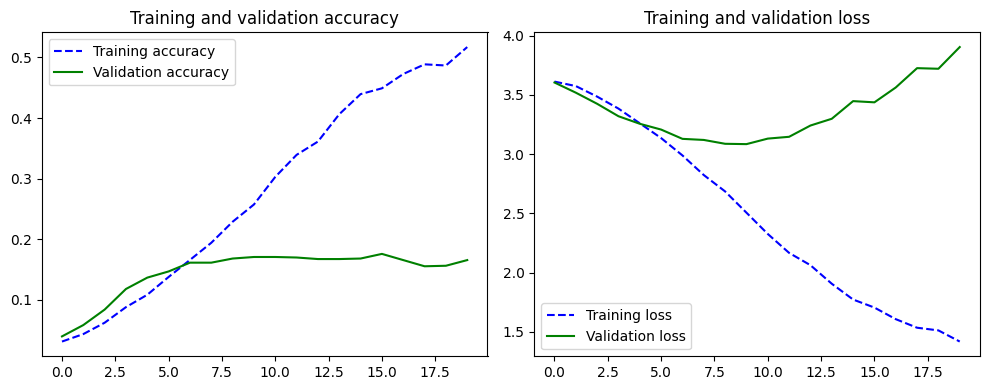

In [19]:
# Nombre de classes (races)
num_classes = len(train_generator.class_indices)

# Création du modèle avec dropout
cnn_mc_do = cnn_multiclass_dropout("cnn_multiclass_dropout", num_classes, drop_rate=0.5)
cnn_mc_do.summary()

# Entrainement (multi-classe)
t_learning_cnn_mc_do, cnn_mc_do_history = Entrainement_multiclass(
    cnn_mc_do,
    train_generator,
    val_generator,
    epochs=20,
    learn_rate=3e-4
)

# Analyse résultats
t_prediction_cnn_mc_do = Analyse_resultats_multiclass(
    cnn_mc_do,
    train_generator,
    val_generator,
    cnn_mc_do_history
)

L’ajout du dropout n’a pas permis de réduire significativement le surapprentissage. Cela s’explique par la complexité du problème (37 classes visuellement proches), la taille limitée du jeu de données et le fait que le dropout n’agit que sur les couches fully-connected, alors que l’extraction des caractéristiques repose principalement sur les couches convolutionnelles.
Remarque : La valeur de la fonction de perte n’est pas bornée entre 0 et 1 car la cross-entropy n’est pas une probabilité mais une mesure logarithmique de l’erreur. Une valeur de loss élevée correspond à une faible probabilité attribuée à la classe correcte, ce qui est fréquent en début d’entraînement, en particulier pour un problème multi-classe avec un grand nombre de catégories.

#### Data Augmentation 

In [20]:
# Data augmentation : on augmente artificiellement la diversité des images
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.15,
    horizontal_flip=True
)

train_generator_aug = train_datagen_aug.flow_from_dataframe(
    train_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_width, img_height),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

# Validation reste sans augmentation (sinon l'évaluation est biaisée)


Found 4703 validated image filenames belonging to 37 classes.


Bien que le nombre d’images du jeu d’entraînement reste inchangé, la data augmentation permet de présenter au modèle des versions modifiées des images à chaque itération, augmentant ainsi la diversité effective des données.

Entrainement de cnn_multiclass_dropout


/home/galuppin/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 31s 119ms/step - accuracy: 0.1379 - loss: 3.5078 - val_accuracy: 0.1607 - val_loss: 3.1124
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.1301 - loss: 3.2131 - val_accuracy: 0.1735 - val_loss: 3.0753
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.1636 - loss: 3.0632 - val_accuracy: 0.1811 - val_loss: 2.9639
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.1715 - loss: 3.0482 - val_accuracy: 0.2134 - val_loss: 2.9299
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.1822 - loss: 3.0035 - val_accuracy: 0.1998 - val_loss: 2.9386
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - accuracy: 0.1680 - loss: 2.9696 - val_accuracy: 0.2126 - val_loss: 2.8653
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - accuracy: 0.1787 - loss: 2.9489 - val_accuracy: 0.2168 - val_loss: 2.8532
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - accuracy: 0.1816 - loss: 2.9493

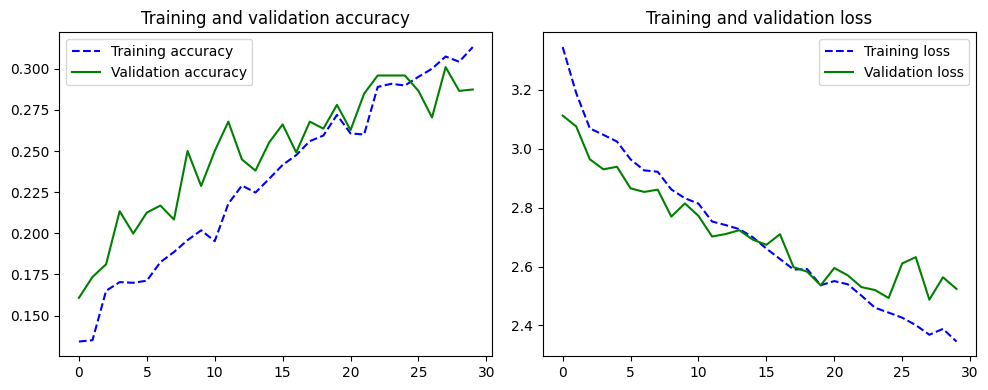

In [21]:
t_learning_cnn_mc_do_aug, cnn_mc_do_aug_history = Entrainement_multiclass(
    cnn_mc_do,
    train_generator_aug,
    val_generator,
    epochs=30,
    learn_rate=3e-4
)

t_prediction_cnn_mc_do_aug = Analyse_resultats_multiclass(
    cnn_mc_do,
    train_generator_aug,
    val_generator,
    cnn_mc_do_aug_history
)

On augmente le nombre d’epochs parce que la data augmentation rend la tâche plus variée, donc l’entraînement peut prendre plus de temps à converger.
Ici il ne surapprend pas mais on va tester du transfer learning pour voir si on fait mieux.

### Utilisation de VGG 16 : pre train network 

In [22]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_vgg = train_datagen_vgg.flow_from_dataframe(
    train_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_width, img_height),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_generator_vgg = val_datagen_vgg.flow_from_dataframe(
    val_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_width, img_height),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_generator_vgg = test_datagen_vgg.flow_from_dataframe(
    test_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_width, img_height),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

num_classes = len(train_generator_vgg.class_indices)
print("Nombre de classes :", num_classes)


Found 4703 validated image filenames belonging to 37 classes.
Found 1176 validated image filenames belonging to 37 classes.
Found 1470 validated image filenames belonging to 37 classes.
Nombre de classes : 37


Dans le cadre du transfer learning avec VGG16, les images sont pré-traitées à l’aide de la fonction preprocess_input, afin de reproduire les conditions exactes d’entraînement du réseau sur ImageNet. L’utilisation d’un simple rescaling n’est pas appropriée dans ce cas, car elle modifierait la distribution des pixels attendue par le modèle pré-entraîné.

In [26]:
conv_base = VGG16(
    weights='imagenet',      # on récupère les poids ImageNet
    include_top=False,       # on enlève la partie Dense originale
    input_shape=(img_width, img_height, 3)
)

conv_base.summary()

# On gèle le backbone : on entraîne seulement la "tête" au début
conv_base.trainable = False

# Construction du modèle complet : VGG16 + head
vgg_combined_mc = Sequential(name="VGG16_multiclass_head")
vgg_combined_mc.add(Input(shape=(img_width, img_height, 3)))
vgg_combined_mc.add(conv_base)
vgg_combined_mc.add(Flatten())
vgg_combined_mc.add(Dense(256, activation='relu'))

# Option dropout (on pourrait sans et je l'ai fait mais ca surapprend un peu donc je le mets)
vgg_combined_mc.add(Dropout(0.3))

# Sortie multi-classe : softmax + num_classes neurones
vgg_combined_mc.add(Dense(num_classes, activation='softmax'))

vgg_combined_mc.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Model: "VGG16_multiclass_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,821,605 (64.17 MB)

 Trainable params: 2,106,917 (8.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [27]:
epochs = 5

# En multi-classe : categorical_crossentropy
vgg_combined_mc.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

t_learning_vgg_mc = time.time()

vgg_combined_mc_history = vgg_combined_mc.fit(
    train_generator_vgg,
    validation_data=val_generator_vgg,
    epochs=epochs
)

t_learning_vgg_mc = time.time() - t_learning_vgg_mc
print("Learning time :", int(t_learning_vgg_mc), "sec")


Epoch 1/5


2026-01-19 12:02:39.781275: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1201', 16 bytes spill stores, 16 bytes spill loads



236/236 ━━━━━━━━━━━━━━━━━━━━ 31s 119ms/step - accuracy: 0.1601 - loss: 17.4681 - val_accuracy: 0.3342 - val_loss: 2.5884
Epoch 2/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.3121 - loss: 2.6775 - val_accuracy: 0.5204 - val_loss: 2.0302
Epoch 3/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.4691 - loss: 2.1521 - val_accuracy: 0.5859 - val_loss: 1.7375
Epoch 4/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - accuracy: 0.5276 - loss: 1.7492 - val_accuracy: 0.6318 - val_loss: 1.5348
Epoch 5/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - accuracy: 0.6052 - loss: 1.5396 - val_accuracy: 0.6531 - val_loss: 1.5727
Learning time : 126 sec


Lors de la phase de transfer learning, seules quelques époques sont nécessaires pour entraîner la tête de classification, le backbone VGG16 étant déjà pré-entraîné sur ImageNet. Cette phase permet de stabiliser les poids avant d’effectuer un fine-tuning plus fin du modèle.

236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.7278 - loss: 0.9803
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6598 - loss: 1.4910
Train accuracy: 0.7282585501670837
Validation accuracy: 0.6530612111091614
Time Prediction: 24.55 seconds


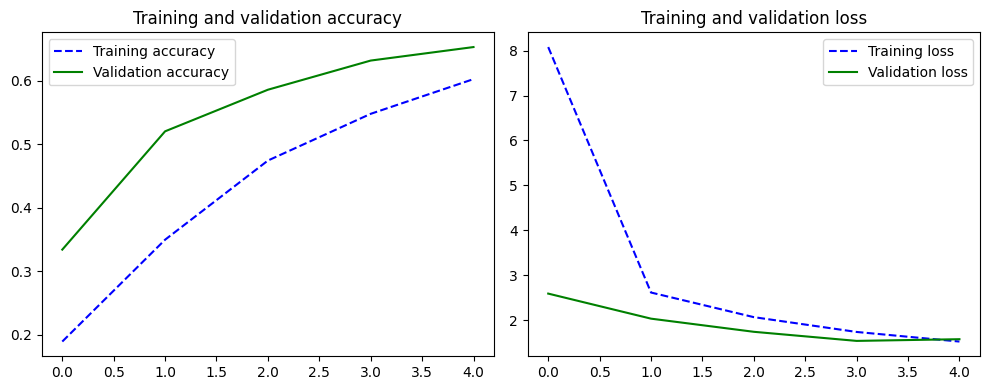

In [28]:
t_prediction_vgg_mc = time.time()

score_vgg_mc_train = vgg_combined_mc.evaluate(train_generator_vgg, verbose=1)
score_vgg_mc_validation = vgg_combined_mc.evaluate(val_generator_vgg, verbose=1)

t_prediction_vgg_mc = time.time() - t_prediction_vgg_mc

print('Train accuracy:', score_vgg_mc_train[1])
print('Validation accuracy:', score_vgg_mc_validation[1])
print("Time Prediction: %.2f seconds" % t_prediction_vgg_mc)

plot_training_analysis(vgg_combined_mc_history)


Lors de la phase de transfer learning, la fonction de perte est initialement élevée en raison de l’initialisation aléatoire de la tête de classification. Elle diminue rapidement car le backbone pré-entraînmé fournit des caractéristiques visuelles pertinentes, permettant à la tête de s’adapter efficacement au jeu de données.

#### Fine tunning

Nombre de couches VGG entraînables : 1
Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.8700 - loss: 0.4082 - val_accuracy: 0.7755 - val_loss: 1.1739
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.8791 - loss: 0.3752 - val_accuracy: 0.7755 - val_loss: 1.1730
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.8661 - loss: 0.4155 - val_accuracy: 0.7755 - val_loss: 1.1719
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - accuracy: 0.8685 - loss: 0.4078 - val_accuracy: 0.7755 - val_loss: 1.1698
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - accuracy: 0.8691 - loss: 0.4086 - val_accuracy: 0.7764 - val_loss: 1.1697
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - accuracy: 0.8568 - loss: 0.4479 - val_accuracy: 0.7755 - val_loss: 1.1695
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - accuracy: 0.8711 - loss: 0.3897 - val_accuracy: 0.7755 - val_loss: 1.1683
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 24s 

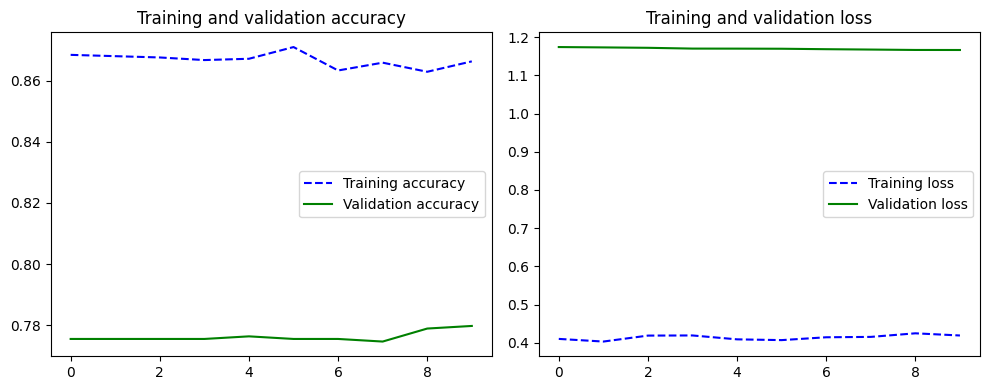

In [31]:
# On dégèle le backbone (mais pas tout)
conv_base.trainable = True

# On garde gelées les premières couches, et on n'entraîne que les dernières
for layer in conv_base.layers[:-1]:
    layer.trainable = False

print("Nombre de couches VGG entraînables :", sum([l.trainable for l in conv_base.layers]))

# IMPORTANT : LR faible pour fine-tuning
vgg_combined_mc.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-6),
    metrics=['accuracy']
)

epochs_ft = 10
t_learning_vgg_mc_ft = time.time()

vgg_mc_ft_history = vgg_combined_mc.fit(
    train_generator_vgg,
    validation_data=val_generator_vgg,
    epochs=epochs_ft
)

t_learning_vgg_mc_ft = time.time() - t_learning_vgg_mc_ft
print("Learning time fine-tuning :", int(t_learning_vgg_mc_ft), "sec")

# Analyse après fine-tuning
t_pred_vgg_mc_ft = Analyse_resultats_multiclass(
    vgg_combined_mc,
    train_generator_vgg,
    val_generator_vgg,
    vgg_mc_ft_history
)


Malgré une stratégie de fine-tuning progressive (dégel d’une seule couche et learning rate très faible), le modèle présente un surapprentissage important. Ce comportement s’explique par la capacité élevée du backbone VGG16 par rapport à la taille du jeu de données. Le transfer learning sans fine-tuning constitue donc la meilleure approche dans notre cas.

### Résultat sur test

In [33]:
t_test = time.time()

score_test = vgg_combined_mc.evaluate(test_generator_vgg, verbose=1)

t_test = time.time() - t_test

print("===== Résultats Test Final =====")
print("Test loss :", score_test[0])
print("Test accuracy :", score_test[1])
print("Time Test: %.2f seconds" % t_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 333ms/step - accuracy: 0.7522 - loss: 1.2478
===== Résultats Test Final =====
Test loss : 1.2311450242996216
Test accuracy : 0.7598639726638794
Time Test: 25.23 seconds


74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step


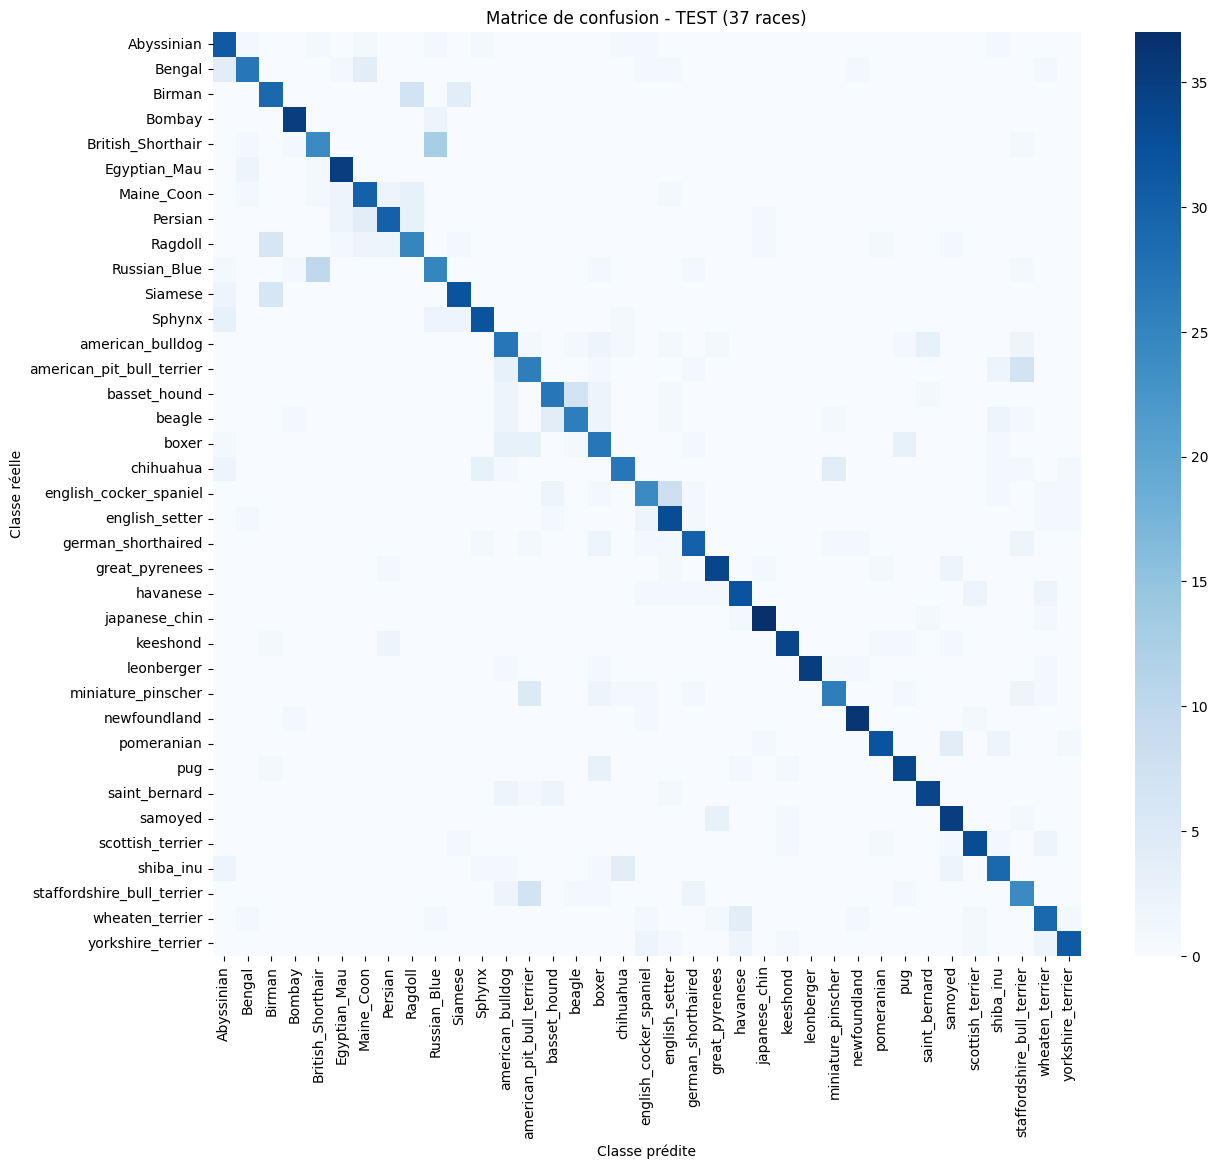

                            precision    recall  f1-score   support

                Abyssinian       0.67      0.79      0.73        39
                    Bengal       0.79      0.68      0.73        40
                    Birman       0.67      0.72      0.70        40
                    Bombay       0.90      0.95      0.92        37
         British_Shorthair       0.65      0.60      0.62        40
              Egyptian_Mau       0.85      0.92      0.89        38
                Maine_Coon       0.73      0.75      0.74        40
                   Persian       0.81      0.75      0.78        40
                   Ragdoll       0.66      0.62      0.64        40
              Russian_Blue       0.57      0.62      0.60        40
                   Siamese       0.80      0.80      0.80        40
                    Sphynx       0.84      0.80      0.82        40
          american_bulldog       0.61      0.68      0.64        40
 american_pit_bull_terrier       0.59      0.65

In [35]:
from sklearn.metrics import confusion_matrix, classification_report

# Liste des labels dans l'ordre des indices Keras
labels = list(test_generator_vgg.class_indices.keys())

# Vraies classes (ids)
y_true_test = test_generator_vgg.classes

# Prédictions
pred_test = vgg_combined_mc.predict(test_generator_vgg, verbose=1)
y_pred_test = np.argmax(pred_test, axis=1)

# Matrice de confusion
cm_test = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(14,12))
sns.heatmap(cm_test, cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Matrice de confusion - TEST (37 races)")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# Rapport détaillé par race (precision/recall/f1)
print(classification_report(y_true_test, y_pred_test, target_names=labels))


## Segmentation

In [ ]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [ ]:

# --- Configuration des chemins (A ajuster selon votre dossier) ---
base_path = "./oxford-iiit-pet/"
img_dir = os.path.join(base_path, "images/")
mask_dir = os.path.join(base_path, "annotations/trimaps/")

# --- Ajout de la colonne des masques ---
# Les masques portent le même nom que l'image, mais en .png
# Votre colonne 'Image' contient déjà l'extension .jpg, on doit la remplacer
df['mask_filename'] = df['Image'].str.replace('.jpg', '.png')

# Vérification que les fichiers existent (optionnel mais recommandé)
# df = df[df['Image'].apply(lambda x: os.path.exists(os.path.join(img_dir, x)))]

# --- Division du Dataset (Train / Val / Test) ---
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['SPECIES_NAME'])
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['SPECIES_NAME'])

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

#### Chargement des Données

In [ ]:
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_data_in_ram(df, img_dir, mask_dir, img_size=(128, 128)):
    images = []
    masks = []
    
    print(f"Chargement de {len(df)} images en cours...")
    
    count = 0
    for _, row in df.iterrows():
        # Chargement Image
        img_path = os.path.join(img_dir, row['Image'])
        img = load_img(img_path, target_size=img_size)
        images.append(img_to_array(img) / 255.0) # Normalisation [0, 1]
        
        # Chargement Masque
        mask_path = os.path.join(mask_dir, row['mask_filename'])
        mask = load_img(mask_path, target_size=img_size, color_mode="grayscale")
        masks.append(img_to_array(mask) - 1) # Correction classes: 1,2,3 -> 0,1,2
        
        count += 1
        if count % 1000 == 0:
            print(f"{count} images traitées")
            
    return np.array(images), np.array(masks)

# Exécution du chargement
# IMG_SIZE doit correspondre à l'entrée de votre modèle (128, 128)
X_train, y_train = load_data_in_ram(train_df, img_dir, mask_dir)
X_val, y_val = load_data_in_ram(val_df, img_dir, mask_dir)

print("Chargement terminé.")
print(f"X_train shape: {X_train.shape}")

#### Implémentation du U-Net

L'architecture U-Net standard comprend une voie de contraction (encodeur) et une voie d'expansion (décodeur) avec des connexions résiduelles (skip connections).

In [ ]:
def build_unet(input_shape, num_classes):
    inputs = Input(input_shape)

    # --- Encodeur (Contraction) ---
    # Bloc 1
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Bloc 2
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bloc 3
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # --- Bottleneck ---
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c4)
    c4 = Dropout(0.3)(c4) # Pour éviter le surapprentissage

    # --- Décodeur (Expansion) ---
    # Bloc 5 (Up 1)
    u5 = UpSampling2D((2, 2))(c4)
    u5 = Concatenate()([u5, c3]) # Skip Connection
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u5)
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c5)

    # Bloc 6 (Up 2)
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c2]) # Skip Connection
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u6)
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c6)

    # Bloc 7 (Up 3)
    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c1]) # Skip Connection
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u7)
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c7)

    # --- Sortie ---
    # 3 classes : Animal, Background, Border -> Softmax
    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(c7)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Construction du modèle
model = build_unet(input_shape=IMG_SIZE + (3,), num_classes=3)
# model.summary()

#### Métriques

Pour compiler le modèle, nous devons définir des métriques adaptées à la segmentation sémantique.

In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    # On convertit les étiquettes en one-hot pour correspondre à la sortie softmax
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=3)
    y_true_one_hot = tf.reshape(y_true_one_hot, shape=tf.shape(y_pred))
    
    intersection = K.sum(y_true_one_hot * y_pred, axis=[0,1,2])
    union = K.sum(y_true_one_hot, axis=[0,1,2]) + K.sum(y_pred, axis=[0,1,2])
    return K.mean( (2. * intersection + smooth) / (union + smooth) )

def iou_coef(y_true, y_pred, smooth=1):
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=3)
    y_true_one_hot = tf.reshape(y_true_one_hot, shape=tf.shape(y_pred))
    
    intersection = K.sum(K.abs(y_true_one_hot * y_pred), axis=[0,1,2])
    union = K.sum(y_true_one_hot,[0,1,2]) + K.sum(y_pred,[0,1,2]) - intersection
    return K.mean((intersection + smooth) / (union + smooth))

#### Entraînement

In [ ]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy', iou_coef, dice_coef])

history = model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    batch_size=64, 
    epochs=15,
    callbacks=callbacks
)

#### Visualisation des résultats 

In [ ]:
def plot_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    iou = history.history['iou_coef']
    val_iou = history.history['val_iou_coef']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))

    # Courbe de perte
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'y', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Courbe IoU
    plt.subplot(1, 2, 2)
    plt.plot(epochs, iou, 'y', label='Training IoU')
    plt.plot(epochs, val_iou, 'r', label='Validation IoU')
    plt.title('Training and Validation IoU')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()

    plt.show()

plot_history(history)

Y'a du sur apprentissage, faut faire de la data augmentation puis si ca marche pas, augmenter le dropout.

In [ ]:
def display_prediction(generator, model, num_samples=10):
    x_val, y_val = generator.__getitem__(0) # Récupérer un batch
    preds = model.predict(x_val)
    
    # La prédiction brute est (128, 128, 3), on prend l'argmax pour avoir la classe (128, 128)
    preds_argmax = np.argmax(preds, axis=-1)
    
    plt.figure(figsize=(20, 20))
    for i in range(num_samples):
        # Image originale
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(x_val[i])
        plt.title("Image")
        plt.axis("off")

        # Vérité terrain (Mask)
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(y_val[i].squeeze(), cmap='jet', vmin=0, vmax=2)
        plt.title("Vérité Terrain")
        plt.axis("off")

        # Prédiction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds_argmax[i], cmap='jet', vmin=0, vmax=2)
        plt.title("Prédiction")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Test de visualisation
display_prediction(test_gen, model)